In [1]:
import psi4
import pandas as pd
import os
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from lps_uscf import lps_solver

In [166]:
csv_file = 'open_shell_15atoms_vs_uhf.csv'

if os.path.exists(csv_file):
    df = pd.read_csv(csv_file)
    print(f"-> Loaded existing results: {len(df)} rows found.")
else:
    df = pd.DataFrame()
    print("-> No existing file found. Starting fresh.")

-> Loaded existing results: 159 rows found.


In [132]:
densities_file = 'densities.pkl'

if os.path.exists(densities_file):
    with open(densities_file, 'rb') as f:
        main_dict = pickle.load(f)
    print(f"Loaded existing database. Keys: {list(main_dict.keys())}")
else:
    main_dict = {}
    print("Created new database.")

Loaded existing database. Keys: ['TFW FA', 'TF0.111111W FA', 'TF0.166666W FA', 'TF0.111111W LDA', 'TF0.333333W FA', 'TF0.2W FA', 'TF0.166666W LDA', 'TF0.166666W PBE']


In [259]:
GUESS_A = psi4.core.Matrix.from_array(main_dict['TF0.111111W FA']['Si']['Da'])
GUESS_B = psi4.core.Matrix.from_array(main_dict['TF0.111111W FA']['Si']['Db'])

In [257]:
psi4.core.set_output_file('output.dat', False)

method = "TF0.111111W PBE"
TP = ['LDA_K_TF', 1.0]
LAMBDA = 0.111111
# EXC = ['LDA_X', 1.0, 'LDA_C_VWN', 0.0]
EXC = ['GGA_X_PBE', 1.0, 'LDA_C_VWN', 0.0]
FA = [False, 1.0]
DIIS = True
MAX_ITER = 20000
DAMPING = [0.99, 0.9, 0.0001]
D_guess = [GUESS_A, GUESS_B]
# D_guess = None
verbose=False

psi4.set_options({'basis': 'UGBS_S', 
                  'DFT_SPHERICAL_POINTS': 6, 
                  'DFT_RADIAL_POINTS': 1000})

multip = 1
atom_label = 'Kr'

mol = psi4.geometry(f"0 {multip}\n {atom_label}\nsymmetry c1")

E, Da, Db, iterations, e_conv, d_conv = lps_solver(MAX_ITER,TP,EXC,LAMBDA,mol,DAMPING,FA,D_guess,DIIS,verbose)
print('\nFinal SCF energy: %.4f Hartree' % E)

if iterations < MAX_ITER:
    
    scf_info_dict = {
    'energy': E,
    'Da': Da.np,
    'Db': Db.np}

    if method not in main_dict:
        main_dict[method] = {}
    if atom_label in main_dict[method]:
        print(f"Skipping {atom_label} (already found).")
    else:
        main_dict[method][atom_label] = scf_info_dict
        with open(densities_file, 'wb') as f:
            pickle.dump(main_dict, f)
        print(f"  -> Saved {atom_label} successfully.")

# GUESS_A = Da
# GUESS_B = Db


Final SCF energy: -2902.2877 Hartree
  -> Saved Kr successfully.


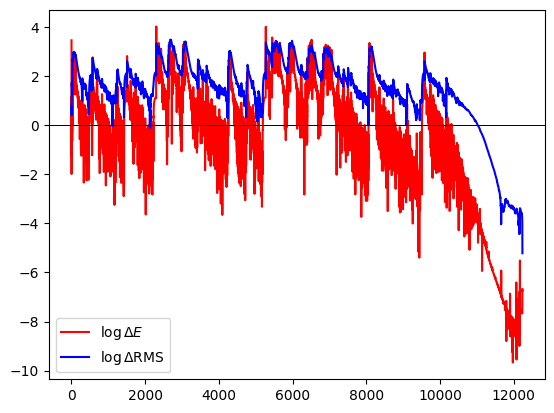

In [258]:
dist = np.linspace(1, iterations, iterations)
plt.plot(dist, e_conv, color = 'red', linestyle='-', label='$\\log{\\Delta E}$')
plt.plot(dist, d_conv, color = 'blue', linestyle='-', label='$\\log{\\Delta\\text{RMS}}$')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.7)
plt.legend()

In [ ]:
psi4.core.set_output_file('output.dat', False)

ATOMS = {
    # Period 3 (Na-Ar)
    # 'Na': {'mult': 2},  # [Ne] 3s1
    # 'Mg': {'mult': 1},  # [Ne] 3s2
    # 'Al': {'mult': 2},  # [Ne] 3s2 3p1
    'Si': {'mult': 3},  # [Ne] 3s2 3p2 
    # 'P':  {'mult': 4},  # [Ne] 3s2 3p3 
    # 'S':  {'mult': 3},  # [Ne] 3s2 3p4
    # 'Cl': {'mult': 2},  # [Ne] 3s2 3p5
    # 'Ar': {'mult': 1},  # [Ne] 3s2 3p6
    # Period 4 (Selected)
    # 'K':  {'mult': 2},  # [Ar] 4s1
    # 'Ca': {'mult': 1},  # [Ar] 4s2
    # 'Cu': {'mult': 2},  # [Ar] 3d10 4s1 
    # 'Zn': {'mult': 1},  # [Ar] 3d10 4s2
    # 'Kr': {'mult': 1},  # [Ar] 3d10 4s2 4p6
}

METHOD = "TF0.111111W PBE"
TP = ['LDA_K_TF', 1.0]
LAMBDA = 0.111111
# EXC = ['LDA_X', 1.0, 'LDA_C_VWN', 0.0]
EXC = ['GGA_X_PBE', 1.0, 'LDA_C_VWN', 0.0]
FA = [False, 1.0]
DIIS = True
MAX_ITER = 20000
DAMPING = [0.99, 0.99, 0.01]
D_guess = [GUESS_A, GUESS_B]
# D_guess = None
verbose=False

psi4.set_options({'basis': 'UGBS_S', 
                  'DFT_SPHERICAL_POINTS': 6, 
                  'DFT_RADIAL_POINTS': 1000})

for atom in ATOMS:
    
    if not df.empty:
        exists = df[
            (df['Atom'] == atom) & 
            (df['Method'] == METHOD) & 
            (df['Basis'] == psi4.core.get_global_option("BASIS"))
        ]
        if not exists.empty:
            print(f"Skipping {atom} (Already exists for {METHOD}/{psi4.core.get_global_option("BASIS")})")
            continue

    print(f"Calculating {atom} with {METHOD}...")
    MOL = psi4.geometry(f"0 {ATOMS[atom]['mult']}\n {atom}\nsymmetry c1")
    try:
        E, Da, Db, iterations, e_conv, d_conv = lps_solver(MAX_ITER,TP,EXC,LAMBDA,MOL,DAMPING,FA,D_guess,DIIS,verbose)
        if iterations >= MAX_ITER:
            print("  !!! SCF failed to converge (Max cycles exceeded).")
        else:
            print(f"Calculated Energy: {E:.4f} Hartree")
            row = {
                "Method": METHOD,
                "Atom": atom,
                "Basis": psi4.core.get_global_option("BASIS"),
                "Grid_Sph": psi4.core.get_global_option("DFT_SPHERICAL_POINTS"),
                "Grid_Rad": psi4.core.get_global_option("DFT_RADIAL_POINTS"),
                "Energy,Ha": round(E, 6),
                "Iterations": iterations,
                "DIIS": DIIS,
                "Damp_Start": DAMPING[0],
                "Damp_End": DAMPING[1],
                "Damp_Cutoff": DAMPING[2]
            }
            
            df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    
    except Exception as e:
        print(f"  !!! Failed {atom}. Error: {e}")
        continue

Calculating Si with TF0.111111W PBE...

WARNING ! SCF did not converge. The final values are printed
  !!! SCF failed to converge (Max cycles exceeded).


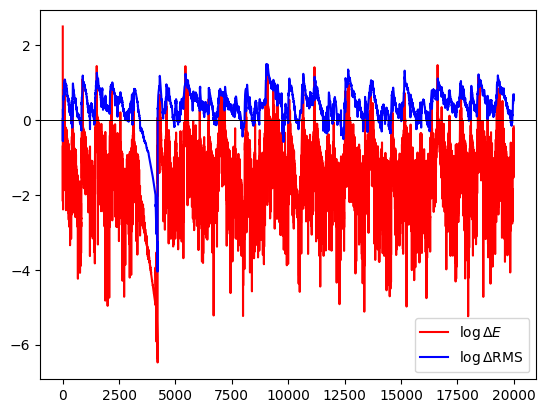

In [279]:
dist = np.linspace(1, iterations, iterations)
plt.plot(dist, e_conv, color = 'red', linestyle='-', label='$\\log{\\Delta E}$')
plt.plot(dist, d_conv, color = 'blue', linestyle='-', label='$\\log{\\Delta\\text{RMS}}$')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.7)
plt.legend()

In [255]:
df.to_csv(csv_file, index=False)
df

,Method,Atom,Basis,Grid_Sph,Grid_Rad,"Energy,Ha",Iterations,DIIS,Damp_Start,Damp_End,Damp_Cutoff
0,TFW LDA,Na,UGBS_S,6,1000,-108.912083,284,True,0.90,0.90,0.00009
1,TFW LDA,Mg,UGBS_S,6,1000,-135.553609,237,True,0.90,0.90,0.00009
2,TFW LDA,Al,UGBS_S,6,1000,-165.669941,387,True,0.90,0.90,0.00009
3,TFW LDA,Si,UGBS_S,6,1000,-199.392286,517,True,0.90,0.90,0.00009
4,TFW LDA,P,UGBS_S,6,1000,-236.833553,342,True,0.90,0.90,0.00009
...,...,...,...,...,...,...,...,...,...,...,...
165,TF0.111111W PBE,Ca,UGBS_S,6,1000,-723.490150,8602,True,0.99,0.99,0.00010
166,TF0.111111W PBE,Na,UGBS_S,6,1000,-176.494488,18189,True,0.99,0.99,0.00010
167,TF0.111111W PBE,Al,UGBS_S,6,1000,-261.669232,15108,True,0.99,0.99,0.00010
168,TF0.111111W PBE,Zn,UGBS_S,6,1000,-1886.161085,32602,True,0.99,0.90,0.00010


In [ ]:
## TF0.111111W PBE for O, F, Zn, Kr used TF0.111111W FA densities
## TF0.111111W FA for Si, Kr, P used TF0.166666W FA initial guess
## TF0.111111W LDA for Si, P used TF0.111111W LDA density of a previous atom
## TF0.166666W PBE for Cl used TF0.166666W LDA initial guess
## TF0.166666W LDA for K, Cl used TF0.166666W FA initial guess
## TF0.166666W FA for Cl used TF0.2W FA initial guess
## TF0.166666W PBE for Kr used TF0.2W PBE initial guess
## TF0.166666W LDA for Kr used TF0.2W FA initial guess
## TF0.166666W LDA for S used TF0.166666W PBE initial guess
## TF0.166666W PBE for Al used TF0.166666W FA initial guess
## TF0.166666W PBE for S used TF0.2W LDA initial guess
## TF0.2W PBE for Cl used TF0.2W FA density
## TF0.2W LDA for S used TF0.333333W LDA density
## TF0.2W PBE for Kr used TF0.333333W PBE density
## TF0.2W FA for Cl used TF0.333333W FA initial guess
## TF0.333333W PBE for Cl used TF0.333333W FA density 

In [280]:
# df = df[~((df['Method'] == 'TF0.2W PBE') & (df['Atom'] == 'Al'))]
# df[(df['Method'] == 'TF0.166666W FA') & (df['Atom'] == 'K')]
df[(df['Method'] == 'TF0.111111W LDA')]

,Method,Atom,Basis,Grid_Sph,Grid_Rad,"Energy,Ha",Iterations,DIIS,Damp_Start,Damp_End,Damp_Cutoff
139,TF0.111111W LDA,Na,UGBS_S,6,1000,-175.220390,4870,True,0.99,0.99,0.00003
140,TF0.111111W LDA,Mg,UGBS_S,6,1000,-215.265035,4402,True,0.99,0.99,0.00003
141,TF0.111111W LDA,Al,UGBS_S,6,1000,-260.117429,14370,True,0.99,0.99,0.00003
142,TF0.111111W LDA,Si,UGBS_S,6,1000,-309.909768,8732,True,0.99,0.90,0.00005
143,TF0.111111W LDA,P,UGBS_S,6,1000,-364.755320,13406,True,0.99,0.99,0.00005
159,TF0.111111W LDA,Ar,UGBS_S,6,1000,-561.816447,5442,True,0.99,0.99,0.00010
160,TF0.111111W LDA,Ca,UGBS_S,6,1000,-720.921710,6140,True,0.99,0.99,0.00010
161,TF0.111111W LDA,Zn,UGBS_S,6,1000,-1882.061216,11354,True,0.99,0.99,0.00010
162,TF0.111111W LDA,Kr,UGBS_S,6,1000,-2897.236588,7295,True,0.99,0.99,0.00010


In [256]:
atom_order = ['Na', 'Mg', 'Al', 'Si', 'P', 'S', 'Cl', 'Ar', 'K', 'Ca', 'Zn', 'Kr']
energy_table = df.pivot(index='Atom', columns='Method', values='Energy,Ha')
energy_table = energy_table.reindex(atom_order)
energy_table

Method,TF0.111111W FA,TF0.111111W LDA,TF0.111111W PBE,TF0.166666W FA,TF0.166666W LDA,TF0.166666W PBE,TF0.2W FA,TF0.2W LDA,TF0.2W PBE,TF0.333333W FA,TF0.333333W LDA,TF0.333333W PBE,TFW FA,TFW LDA,TFW PBE
Atom,,,,,,,,,,,,,,,
Na,-169.876758,-175.220390,-176.494488,-161.083133,-166.247018,-167.439022,-156.665459,-161.732209,-162.884191,-142.690045,-147.423156,-148.454126,-105.226002,-108.912083,-109.651463
Mg,-208.826727,-215.265035,-216.678698,-198.305386,-204.540681,-205.864548,-193.013833,-199.138984,-200.419079,-176.244867,-181.989422,-183.137203,-131.025067,-135.553609,-136.382297
Al,-252.536872,-260.117429,-261.669232,-240.123724,-247.478726,-248.933421,-233.874058,-241.106354,-242.513713,-214.036249,-220.842857,-222.107058,-160.241930,-165.669941,-166.588302
Si,-301.135691,-309.909768,NaN,-286.667497,-295.193987,-296.779753,-279.375910,-287.767440,-289.302316,-256.195211,-264.117075,-265.498027,-193.008025,-199.392286,-200.400917
P,-354.731372,-364.755320,NaN,-338.045378,-347.799950,-349.517759,-329.628312,-339.235807,-340.899147,-302.831533,-311.925851,-313.424434,-229.434658,-236.833553,-237.933265
S,-413.577377,NaN,NaN,-394.530559,-405.745598,-407.603230,-384.915848,-395.968957,-397.768400,-354.272546,-364.758190,-366.381630,-270.014427,-278.601238,-279.798321
Cl,NaN,NaN,NaN,-456.106275,-468.830862,-470.828673,-445.209435,-457.757749,-459.693620,-410.442846,-422.371240,-424.119790,-314.492584,-324.324636,-325.619280
Ar,-547.190764,-561.816447,-564.088988,-522.928926,-537.208760,-539.346529,-510.665243,-524.754841,-526.826944,-471.497581,-484.916246,-486.789800,-363.016580,-374.146432,-375.538832
K,NaN,NaN,NaN,-595.127590,-611.008714,NaN,-581.412138,-597.089205,NaN,-537.564831,-552.520707,-554.518805,-415.710015,-428.188235,-429.678591


In [ ]:
ATOMS = {
    'He':  {'mult': 1}, 
    'Be': {'mult': 1},
    'Ne': {'mult': 1}, 
    'Mg': {'mult': 1},
    'Ar':  {'mult': 1}, 
    'Ca':  {'mult': 1},
    'Zn':  {'mult': 1}, 
    'Kr':  {'mult': 1}
}
psi4.core.set_output_file('output.dat', False)
psi4.set_options({'basis': 'UGBS',
                  'scf_type': 'PK'})
rhf_energies = {}
rhf_homos = {}
for atom in ATOMS:
    MOL = psi4.geometry(f"0 {ATOMS[atom]['mult']}\n {atom}\nsymmetry c1")
    E, wfn = psi4.energy('SCF', return_wfn=True)
    rhf_energies[atom] = round(E, 6)
    print(f"RHF/UGBS {atom} Energy: {E:.4f} Hartree")

RHF/UGBS He Energy: -2.8617 Hartree, IP: -0.9180
RHF/UGBS Be Energy: -14.5730 Hartree, IP: -0.3093
RHF/UGBS Ne Energy: -128.5471 Hartree, IP: -0.8504
RHF/UGBS Mg Energy: -199.6146 Hartree, IP: -0.2530
RHF/UGBS Ar Energy: -526.8175 Hartree, IP: -0.5910
RHF/UGBS Ca Energy: -676.7582 Hartree, IP: -0.1955
RHF/UGBS Zn Energy: -1777.8481 Hartree, IP: -0.2925
RHF/UGBS Kr Energy: -2752.0549 Hartree, IP: -0.5242


In [26]:
atom_order = ['He', 'Be', 'Ne', 'Mg', 'Ar', 'Ca', 'Zn', 'Kr']
energy_table = df.pivot(index='Atom', columns='Method', values='Energy,Ha')
energy_table = energy_table.reindex(atom_order)
energy_table['RHF/UGBS'] = pd.Series(rhf_energies)
new_order = ['TFD0.166666W', 'TF0.166666W PBEx', 'TF0.166666W FA', 'RHF/UGBS']
energy_table = energy_table[new_order]

In [28]:
reference = energy_table['RHF/UGBS']

res = {}
for method, energies in energy_table.items():
    if method == 'RHF/UGBS': 
        continue 
    
    mae  = (energies - reference).abs().mean()
    rmae = (((energies - reference).abs()) / reference * -100).mean()
    res[method] = round(mae, 2), round(rmae, 2)

mae_row  = {method: values[0] for method, values in res.items()}
rmae_row = {method: values[1] for method, values in res.items()}
stats_df = pd.DataFrame([mae_row, rmae_row], index=['MAE(Ha)', 'rMAE(%)'])
energy_table = pd.concat([energy_table, stats_df], sort=False)

In [29]:
display(energy_table)

,TFD0.166666W,TF0.166666W PBEx,TF0.166666W FA,RHF/UGBS
He,-2.951247,-3.097069,-3.019526,-2.861680
Be,-15.040391,-15.388877,-14.660508,-14.573023
Ne,-132.508856,-133.573716,-128.291707,-128.547083
Mg,-204.540690,-205.864549,-198.305386,-199.614621
Ar,-537.208760,-539.346529,-522.928926,-526.817486
Ca,-690.396266,-692.814969,-672.808485,-676.758154
Zn,-1812.192490,-1816.067937,-1773.727670,-1777.848060
Kr,-2795.914635,-2800.696590,-2741.665221,-2752.054860
MAE(Ha),13.960000,15.970000,3.020000,NaN
rMAE(%),2.420000,3.690000,1.110000,NaN
